<a href="https://colab.research.google.com/github/LucioFassarella/AMQ/blob/main/Perceptorn69_ago25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PROCESSAMENTO

In [1]:
'''
Métodos auxiliares
'''

def binfloat(f, num_digitos = int):
    whole, dec = str(f).split(".")
    res = bin(int(whole))[2:] + "."

    dec = float("0." + dec)
    for _ in range(num_digitos):
        dec *= 2
        bit = int(dec)
        res += str(bit)
        dec -= bit
        if dec == 0: break

    #aproximação binária para resultado igual a 1
    if(res==1.0):
      res = 0.1111
    return res

import cv2
import numpy as np

def analyze_pixel_distribution(img_binary):
    """
    Analisa a distribuição de bits 1 (objeto) nas 4 metades da imagem.
    Assume que: Objeto = 1, Fundo = 0.
    Parâmetros:
      img_binary: imagem contendo 0 e 1.
    Retorna:
      features_images: dicionário contendo as features da imagem inteira.
      features_bbox: dicionário de bits contendo as features apenas dentro da
      delimitação da imagemm
    """
    # Garante que a imagem está em 1 único canal (escala de cinza/binária)
    if len(img_binary.shape) == 3:
        img_binary = cv2.cvtColor(img_binary, cv2.COLOR_BGR2GRAY)

    # Converte para uint8 para compatibilidade com cv2.threshold
    img_binary = img_binary.astype(np.uint8)

    # Garante que a imagem está estritamente binária com valores 0 e 1
    # (Se vier do OpenCV padrão onde branco é 255, isso converte para 1)
    _, img_bin = cv2.threshold(img_binary, 0, 1, cv2.THRESH_BINARY)

    height, width = img_bin.shape[:2]

    # -------------------------------------------------------------
    # ABORDAGEM 1: Contagem considerando a imagem INTEIRA
    # -------------------------------------------------------------
    # mid_y = height // 2
    # mid_x = width // 2

    # # Recorta as fatias da imagem e soma os bits 1
    # total_superior = np.sum(img_bin[0:mid_y, :])
    # total_inferior = np.sum(img_bin[mid_y:height, :])
    # total_esquerda = np.sum(img_bin[:, 0:mid_x])
    # total_direita  = np.sum(img_bin[:, mid_x:width])

    # -------------------------------------------------------------
    # ABORDAGEM 2: Contagem focada apenas na Bounding Box do número
    # (Evita que o posicionamento do número na tela altere o resultado)
    # -------------------------------------------------------------
    # Encontra onde estão os bits 1 (o número desenhado)
    pts = np.argwhere(img_bin == 1)

    if len(pts) == 0:
        # Imagem vazia (sem nenhum bit 1)
        bb_superior = bb_inferior = bb_esquerda = bb_direita = 0
    else:
        # Coordenadas da Bounding Box: [ymin, xmin] até [ymax, xmax]
        ymin, xmin = pts.min(axis=0)
        ymax, xmax = pts.max(axis=0)

        # Recorta apenas a região ocupada pelo número
        roi = img_bin[ymin:ymax+1, xmin:xmax+1]
        roi_h, roi_w = roi.shape

        # Define os meios da Bounding Box
        roi_mid_y = roi_h // 2
        roi_mid_x = roi_w // 2

        # Conta os bits 1 dentro das metades da Bounding Box
        bb_superior = np.sum(roi[0:roi_mid_y, :])
        bb_inferior = np.sum(roi[roi_mid_y:roi_h, :])
        bb_esquerda = np.sum(roi[:, 0:roi_mid_x])
        bb_direita  = np.sum(roi[:, roi_mid_x:roi_w])
    '''
    # Exibe os resultados
    print("=" * 50)
    print("      CONTAGEM DE BITS 1 (MÉTRICAS DA IMAGEM)")
    print("=" * 50)
    print(f"Dimensões da imagem: {width}x{height}")
    print("-" * 50)
    print("CONSIDERANDO A IMAGEM INTEIRA:")
    print(f"  • Metade Superior: {total_superior} bits")
    print(f"  • Metade Inferior: {total_inferior} bits")
    print(f"  • Metade Esquerda: {total_esquerda} bits")
    print(f"  • Metade Direita:  {total_direita} bits")
    print("-" * 50)
    print("CONSIDERANDO APENAS A BOUNDING BOX DO NÚMERO:")
    print(f"  • Metade Superior: {bb_superior} bits")
    print(f"  • Metade Inferior: {bb_inferior} bits")
    print(f"  • Metade Esquerda: {bb_esquerda} bits")
    print(f"  • Metade Direita:  {bb_direita} bits")
    print("=" * 50)
    '''
    # Retorna os dicionários
    # features_imagem = {"sup": total_superior, "inf": total_inferior,
    #                    "esq": total_esquerda, "dir": total_direita}
    features_bbox = {"sup": bb_superior, "inf": bb_inferior, "esq": bb_esquerda,
                     "dir": bb_direita}
    '''
    if(features_imagem["inf"]==0):
      Hr = features_imagem["sup"]/1.0
    else:
      Hr = features_imagem["sup"]/features_imagem["inf"]

    if(features_imagem["dir"]==0):
      Vr= features_imagem["esq"]/1.0
    else:
      Vr = features_imagem["esq"]/features_imagem["dir"]
    '''
    if(features_bbox["inf"]==0):
      Hr = features_bbox["sup"]/1.0
    else:
      Hr = features_bbox["sup"]/features_bbox["inf"]

    if(features_bbox["dir"]==0):
      Vr= features_bbox["esq"]/1.0
    else:
      Vr = features_bbox["esq"]/features_bbox["dir"]

    return Hr, Vr

import numpy as np

def importar_pbm_p1(caminho_arquivo):
    """
    Lê um arquivo PBM (formato P1 ASCII), ignorando comentários,
    e retorna uma matriz binária (NumPy array).
    """
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    dados_uteis = []
    largura = 0
    altura = 0
    dimensoes_encontradas = False

    for linha in linhas:
        linha = linha.strip()

        # Ignora linhas vazias ou comentários
        if not linha or linha.startswith('#'):
            continue

        # Pula o cabeçalho 'P1' se ele existir no arquivo
        if linha == 'P1':
            continue

        # A primeira linha que não é comentário/P1 deve ser a dimensão (ex: "128 128")
        if not dimensoes_encontradas:
            partes = linha.split()
            largura = int(partes[0])
            altura = int(partes[1])
            dimensoes_encontradas = True
            continue

        # O que sobrar são os bits da imagem
        dados_uteis.append(linha)

    # Junta todas as linhas de bits em uma única string e remove espaços se houver
    string_bits = "".join(dados_uteis).replace(" ", "").replace("\n", "")

    # Converte a string de caracteres '0' e '1' em uma lista de inteiros
    lista_pixels = [int(bit) for bit in string_bits]

    # Transforma em uma matriz bidimensional (Numpy Array) com as dimensões corretas
    matriz_imagem = np.array(lista_pixels).reshape((altura, largura))

    return matriz_imagem

#Passo 1.1:Importando Dados Teste
def importar_pacote_imagens_pbm(caminho_pasta, numero_inicial, quantidade):
    """
    Importa uma sequência de arquivos .pbm numerados sequencialmente a partir de um diretório.

    Parâmetros:
    - caminho_pasta (str): Caminho do diretório onde as imagens estão (ex: "/content/.../8/")
    - numero_inicial (int): O número do primeiro arquivo a ser importado (ex: 850)
    - quantidade (int): Quantidade de imagens a serem importadas em sequência (padrão: 6)

    Retorna:
    - list: Lista contendo as matrizes das imagens importadas com sucesso.
    """

    import os

    if quantidade is None:
        quantidade = len(os.listdir('caminho_pasta'))

    lista_de_matrizes = []
    numero_atual = numero_inicial

    # Garante que o caminho da pasta termine com uma barra para não quebrar a string
    if not caminho_pasta.endswith('/'):
        caminho_pasta += '/'

    for i in range(quantidade):
        # Monta o caminho completo usando os parâmetros dinâmicos
        caminho_completo = f"{caminho_pasta}{numero_atual}.pbm"

        try:
            # Importa a matriz atual usando função importar_pbm_p1
            matriz_atual = importar_pbm_p1(caminho_completo)

            # Adiciona a matriz na lista de armazenamento
            lista_de_matrizes.append(matriz_atual)
            print(f"[{i+1}/{quantidade}] {caminho_completo} importado com sucesso!")

        except FileNotFoundError:
            print(f"Erro: O arquivo {caminho_completo} não foi encontrado. Interrompendo importação.")
            break  # Para o loop se um arquivo falhar

        # Incrementa para o próximo número de arquivo
        numero_atual += 1

    # --- Resumo pós-loop ---
    print("\n--- Resumo da Importação ---")
    if lista_de_matrizes:
        print(f"Total de {len(lista_de_matrizes)} imagens importadas com sucesso!")
        # Verifica se o objeto retornado possui o atributo shape (como matrizes NumPy)
        if hasattr(lista_de_matrizes[0], 'shape'):
            print(f"Formato de cada matriz: {lista_de_matrizes[0].shape}")
    else:
        print("Nenhuma imagem foi importada.")

    return lista_de_matrizes

#PASSO 2: Extraindo Hr, Vr
def extrair_caracteristicas_imagens(lista_de_matrizes, exibir=True):
    """
    Obtém as razões horizontais (Hr) e verticais (Vr) de uma lista de imagens binárias.

    Parâmetros:
    - lista_de_matrizes (list): Lista contendo as matrizes das imagens.
    - exibir (bool): Se True, imprime a lista formatada na tela.

    Retorna:
    - list: Lista de listas no formato [[Hr, Vr], [Hr, Vr], ...] com valores float.
    """
    lista_hr_vr = []

    # Passo 3: Processa cada imagem para obter Hr e Vr
    for matriz in lista_de_matrizes:
        Hr, Vr = analyze_pixel_distribution(matriz)
        lista_hr_vr.append([float(Hr), float(Vr)]) # Garante que os valores sejam float

    # Imprime os resultados se verbose for True
    if exibir:
        for i, valores in enumerate(lista_hr_vr):
            print(f"Lista_hr_vr[{i}]: {valores}")

    return lista_hr_vr

#PASSO 4: NORMALIZAR DADOS OBTIDOS NO PASSO ANTERIOR

def fator_normaliza(lista_hr_vr):
    """
    Calcula os fatores de normalização (maior valor de Hr e Vr)
    # Encontra o maior valor de Hr (índice 0) e Vr (índice 1)
    """
    max_hr = max(lista_hr_vr, key=lambda x: x[0])[0]
    max_vr = max(lista_hr_vr, key=lambda x: x[1])[1]

    return max_hr, max_vr

def normalizar_caracteristicas(lista_hr_vr, max_hr, max_vr, exibir=True):
    """
    Normaliza os valores de Hr e Vr dividindo-os pelo maior valor de cada coluna.
    Substitui o valor 1.0 por 0.1111 caso a normalização resulte em 1.

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...]
    - exibir (bool): Se True, imprime a lista normalizada na tela.

    Retorna:
    - list: Nova lista com os valores devidamente normalizados.
    """

    lista_normalizada = []

    # Processa e normaliza cada par [Hr, Vr]
    i = 0
    for item in lista_hr_vr:
        i += 1
        item[0] = item[0] / max_hr
        item[1] = item[1] / max_vr

        # Aplica a sua regra de corte para evitar o valor 1.0
        '''
        if hr_norm == 1.0:
            hr_norm = 0.1111

        if vr_norm == 1.0:
            vr_norm = 0.1111
        '''

        # Adiciona os valores transformados à nova lista
        lista_normalizada.append([item[0], item[1]])

        if exibir:
            print(f"Lista_hr_vr[{i}]: [{item[0]}, {item[1]}]")

    return lista_normalizada

#PASSO 5: TRANSFORMAR DADOS PARA VALORES BINÁRIOS

def converter_recursos_para_binario(lista_hr_vr, num_digitos=7, exibir=True):
    """
    Converte os valores float (Hr e Vr) de uma lista para suas representações binárias
    utilizando a função binfloat().

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...] com valores float.
    - num_digitos (int): Quantidade de dígitos/bits para a conversão (padrão: 8).
    - exibir (bool): Se True, imprime a lista convertida na tela.

    Retorna:
    - list: Nova lista contendo os valores convertidos em binário pela função binfloat.
    """
    lista_binaria = []

    # Passo 5: Aplica a função binfloat em cada valor de Hr e Vr
    for i, par in enumerate(lista_hr_vr):
        hr_bin = binfloat(par[0], num_digitos=num_digitos)
        vr_bin = binfloat(par[1], num_digitos=num_digitos)

        # Adiciona o par convertido à nova lista
        lista_binaria.append([hr_bin, vr_bin])

        if exibir:
            print(f"Lista_hr_vr[{i}]: [{hr_bin}, {vr_bin}]")

    return lista_binaria

#Paso 6.1: ORGANIZANDO DADOS
def mesclar_recursos_binarios(lista_hr_vr_binaria, exibir=True):
    """
    Mescla (concatena) os componentes binários Hr e Vr de cada imagem em uma única string.

    Parâmetros:
    - lista_hr_vr_binaria (list): Lista de listas no formato [[hr_bin, vr_bin], ...]
    - verbose (bool): Se True, imprime a lista mesclada na tela.

    Retorna:
    - list: Nova lista contendo as strings binárias mescladas (ex: ['01011100', ...]).
    """
    lista_mesclada = []

    # Passo 6.1: Mesclar Hr e Vr em um elemento só
    for i, par in enumerate(lista_hr_vr_binaria):
        # Concatena a string do Hr com a string do Vr
        recurso_mesclado = par[0] + par[1]
        lista_mesclada.append(recurso_mesclado)

        if exibir:
            print(f"ListaHrVr[{i}]: {recurso_mesclado}")

    return lista_mesclada

#PASSO 6.2: ORGANIZANDO DADOS:
def transformar_para_vetor_bits(lista_hr_vr_binaria, exibir=True):
    """
    Transforma os elementos em strings, remove apenas os pontos decimais
    e converte absolutamente todos os dígitos (incluindo os zeros) em um vetor de inteiros.
    """
    lista_vetores_finais = []

    for i, elemento in enumerate(lista_hr_vr_binaria):
        # 1. Se o elemento for uma lista/tupla (ex: ['0.111.100']), junta em uma string só
        if isinstance(elemento, (list, tuple)):
            texto_puro = "".join(str(x) for x in elemento)
        else:
            texto_puro = str(elemento)

        # 2. Remove APENAS o caractere de ponto decimal
        string_sem_pontos = texto_puro.replace(".", "")

        # 3. Transforma cada caractere numérico em um número inteiro, mantendo todos os zeros
        vetor_bits = [int(bit) for bit in string_sem_pontos if bit.isdigit()]

        # 4. Guarda o vetor na lista final
        lista_vetores_finais.append(vetor_bits)

        if exibir:
            print(f"ListaHrVr[{i}]: {vetor_bits}")

    return lista_vetores_finais

#PASSO 7: CLASSIFICANDO DADOS
def adicionar_exemplos_ao_dataset(lista_vetores, classe, lista_dados_existente=None, exibir=True):
    """
    Adiciona os vetores de bits e suas respectivas classificações (labels)
    a uma lista unificada de dados.

    Parâmetros:
    - lista_vetores (list): Lista de vetores de bits (saída do Passo 6.2).
    - classe (int): O rótulo da classe (ex: 0 para o caractere 4, 1 para o caractere 8).
    - lista_dados_existente (list): Uma lista existente para acumular os dados. Se None, cria uma nova.
    - exibir (bool): Se True, imprime a lista de dados na tela.

    Retorna:
    - list: Lista atualizada contendo pares no formato [vetor_bits, classe].
    """
    # Se não for passada uma lista existente, inicializa uma nova vazia
    if lista_dados_existente is None:
        lista_dados_existente = []

    # Armazena o índice inicial para o print correto no modo verbose
    indice_inicial = len(lista_dados_existente)

    # Passo 7: Adiciona cada vetor com sua respectiva classificação
    for vetor in lista_vetores:
        lista_dados_existente.append([vetor, classe])

    if exibir:
        for i in range(indice_inicial, len(lista_dados_existente)):
            print(f"ListaDados[{i}]: {lista_dados_existente[i]}")

    return lista_dados_existente

In [2]:
'''
Montagem de drive
'''

from google.colab import drive
drive.mount('/content/drive')

# Conteúdo

import os

# print("Conteúdo de '/content/drive/MyDrive/Colab Notebooks/OCR':")
# print(os.listdir('/content/drive/MyDrive/Colab Notebooks/OCR/6'))

Mounted at /content/drive


In [3]:
'''
LISTA 6
'''

#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_6 = "/content/drive/MyDrive/Colab Notebooks/OCR/6/"#"/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/seis/"

# Chamando a função
matrizes_treino_6 = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_6,
    numero_inicial=600,
    quantidade=50
)

#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_9 = "/content/drive/MyDrive/Colab Notebooks/OCR/9/"#"/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/nove/"


# Chamando a função
matrizes_treino_9 = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_9,
    numero_inicial=900,
    quantidade=50
)

###############################################

'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
lista_6_treino = extrair_caracteristicas_imagens(matrizes_treino_6, exibir=True)

del lista_6_treino[21]


lista_6 = lista_6_treino.copy()

display(lista_6)

print(len(lista_6_treino))

'''
Lista 9
'''

lista_9_treino = extrair_caracteristicas_imagens(matrizes_treino_9, exibir=True)

#del lista_4_treino[21]


lista_9 = lista_9_treino.copy()

display(lista_9)

print(len(lista_9_treino))

[1/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/600.pbm importado com sucesso!
[2/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/601.pbm importado com sucesso!
[3/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/602.pbm importado com sucesso!
[4/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/603.pbm importado com sucesso!
[5/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/604.pbm importado com sucesso!
[6/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/605.pbm importado com sucesso!
[7/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/606.pbm importado com sucesso!
[8/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/607.pbm importado com sucesso!
[9/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/608.pbm importado com sucesso!
[10/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/609.pbm importado com sucesso!
[11/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/610.pbm importado com sucesso!
[12/50] /content/drive/MyDrive/Colab Notebooks/OCR/6/611.pbm importado com sucesso!
[

[[0.3132716049382716, 1.2277486910994764],
 [0.38839285714285715, 1.0733333333333333],
 [0.49382716049382713, 1.388157894736842],
 [0.47010309278350515, 1.2006172839506173],
 [0.45962732919254656, 1.079646017699115],
 [0.38571428571428573, 1.7626582278481013],
 [0.4165103189493433, 0.9509043927648578],
 [0.5486725663716814, 1.0068807339449541],
 [0.4552380952380952, 1.0482573726541555],
 [0.3483483483483483, 1.4875346260387812],
 [0.32195121951219513, 1.2489626556016598],
 [0.354656632173095, 0.7910447761194029],
 [0.42857142857142855, 1.065217391304348],
 [0.3881856540084388, 1.05625],
 [0.6099173553719008, 0.7117750439367311],
 [0.47875816993464054, 1.0662100456621004],
 [0.48997772828507796, 1.1650485436893203],
 [0.3283208020050125, 1.314410480349345],
 [0.3470790378006873, 1.6133333333333333],
 [0.5148514851485149, 1.0675675675675675],
 [0.36675461741424803, 0.7923875432525952],
 [0.4929906542056075, 1.0746753246753247],
 [0.4188034188034188, 1.0815047021943573],
 [0.3327974276527

49
Lista_hr_vr[0]: [2.0968992248062017, 0.779510022271715]
Lista_hr_vr[1]: [2.476470588235294, 0.7331378299120235]
Lista_hr_vr[2]: [2.0, 1.1929824561403508]
Lista_hr_vr[3]: [2.4444444444444446, 1.1592039800995024]
Lista_hr_vr[4]: [2.1169590643274856, 1.337719298245614]
Lista_hr_vr[5]: [2.1243523316062176, 0.5382653061224489]
Lista_hr_vr[6]: [2.0672268907563027, 0.9466666666666667]
Lista_hr_vr[7]: [2.3482587064676617, 1.2813559322033898]
Lista_hr_vr[8]: [2.2337662337662336, 0.9402597402597402]
Lista_hr_vr[9]: [1.8783269961977187, 0.9713541666666666]
Lista_hr_vr[10]: [1.4054669703872438, 0.6171516079632465]
Lista_hr_vr[11]: [2.0869565217391304, 1.0579710144927537]
Lista_hr_vr[12]: [1.9891304347826086, 0.9713261648745519]
Lista_hr_vr[13]: [2.5307692307692307, 0.8850102669404517]
Lista_hr_vr[14]: [2.3006134969325154, 0.8680555555555556]
Lista_hr_vr[15]: [2.9404255319148938, 0.9956896551724138]
Lista_hr_vr[16]: [1.8126984126984127, 1.467966573816156]
Lista_hr_vr[17]: [2.7027027027027026, 0.

[[2.0968992248062017, 0.779510022271715],
 [2.476470588235294, 0.7331378299120235],
 [2.0, 1.1929824561403508],
 [2.4444444444444446, 1.1592039800995024],
 [2.1169590643274856, 1.337719298245614],
 [2.1243523316062176, 0.5382653061224489],
 [2.0672268907563027, 0.9466666666666667],
 [2.3482587064676617, 1.2813559322033898],
 [2.2337662337662336, 0.9402597402597402],
 [1.8783269961977187, 0.9713541666666666],
 [1.4054669703872438, 0.6171516079632465],
 [2.0869565217391304, 1.0579710144927537],
 [1.9891304347826086, 0.9713261648745519],
 [2.5307692307692307, 0.8850102669404517],
 [2.3006134969325154, 0.8680555555555556],
 [2.9404255319148938, 0.9956896551724138],
 [1.8126984126984127, 1.467966573816156],
 [2.7027027027027026, 0.8327759197324415],
 [1.951219512195122, 1.0302013422818792],
 [3.0327868852459017, 0.7202797202797203],
 [1.6633165829145728, 1.0463320463320462],
 [2.1853932584269664, 1.0469314079422383],
 [2.5611510791366907, 1.0454545454545454],
 [2.3012048192771086, 1.0679245

50


In [4]:
'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''

#del Lista_6_hr_vr_treino[21]

len(lista_6_treino)

Lista_6 = lista_6_treino.copy()

# Added a check to prevent calling fator_normaliza with an empty list
if Lista_6:
    max_hr_6, max_vr_6 = fator_normaliza(Lista_6)
else:
    print("Warning: Lista_6 is empty. Cannot calculate max_hr_6 and max_vr_6.")
    max_hr_6, max_vr_6 = 0.0, 0.0 # Assign default values or handle as appropriate

len(lista_9_treino)

Lista_9 = lista_9_treino.copy()

# Added a check to prevent calling fator_normaliza with an empty list
if Lista_9:
    max_hr_9, max_vr_9 = fator_normaliza(Lista_9)
else:
    print("Warning: Lista_9 is empty. Cannot calculate max_hr_9 and max_vr_9.")
    max_hr_9, max_vr_9 = 0.0, 0.0 # Assign default values or handle as appropriate

In [5]:
"""
MIX
"""

max_hr = max(max_hr_6, max_hr_9)
max_vr = max(max_vr_6, max_vr_9)

print(max_hr, max_vr)

3.0327868852459017 1.7626582278481013


In [6]:
"""
LISTA 6
"""
# lista_hr_vr_total = []
# lista_hr_vr_total.extend(Lista_4)
# lista_hr_vr_total.extend(Lista_8)

if not lista_6_treino:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_6_normalizada_treino = []
else:
    Lista_6_normalizada_treino = normalizar_caracteristicas(lista_6_treino, max_hr, max_vr)

# DESLOCAMENTO

Lista_6n = Lista_6_normalizada_treino.copy()
#Lista_8 = [[item[0]*1 - 1.0,item[1]*1.0 - 1.0] for item in Lista_8_normalizada_treino]

#####

Lista_6_hr_vr = converter_recursos_para_binario(Lista_6n)

Lista_6_hr = [float(item[0]) for item in Lista_6_hr_vr]
Lista_6_vr = [float(item[1]) for item in Lista_6_hr_vr]
h_index_max = Lista_6_hr.index(max(Lista_6_hr))
v_index_max = Lista_6_vr.index(max(Lista_6_vr))
print(f"h_index_max: {h_index_max}")
print(f"v_index_max: {v_index_max}")
Lista_6_hr_vr[h_index_max][0] = '0.1111111'
Lista_6_hr_vr[v_index_max][1] = '0.1111111'
Lista_6_hr_vr

Lista_6_hr_vr = mesclar_recursos_binarios(Lista_6_hr_vr)

Lista_6_HrVr_binaria = transformar_para_vetor_bits(Lista_6_hr_vr)



"""
LISTA 9
"""

if not lista_9_treino:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_9_normalizada_treino = []
else:
    Lista_9_normalizada_treino = normalizar_caracteristicas(lista_9_treino, max_hr, max_vr)
# if not Lista_4_hr_vr_treino:
#     print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
#     Lista_4_normalizada_treinon = []
# else:
#     Lista_4_normalizada_treinon = normalizar_caracteristicas(Lista_4_hr_vr_treino, 1, 1)

# DESLOCAMENTO

Lista_9n = Lista_9_normalizada_treino.copy()
#Lista_4n = Lista_4_normalizada_treinon.copy()
#Lista_4 = [[item[0]*1.0 - 1.0, item[1]*1.0 - 1.0] for item in Lista_4_normalizada_treino]

####################################

len(Lista_9n)

Lista_9_hr_vr = converter_recursos_para_binario(Lista_9n)

Lista_9_hr = [float(item[0]) for item in Lista_9_hr_vr]
Lista_9_vr = [float(item[1]) for item in Lista_9_hr_vr]
h_index_max = Lista_9_hr.index(max(Lista_9_hr))
v_index_max = Lista_9_vr.index(max(Lista_9_vr))
print(f"h_index_max: {h_index_max}")
print(f"v_index_max: {v_index_max}")
Lista_9_hr_vr[h_index_max][0] = '0.1111111'
Lista_9_hr_vr[v_index_max][1] = '0.1111111'
Lista_9_hr_vr

Lista_9_hr_vr = mesclar_recursos_binarios(Lista_9_hr_vr)

Lista_9_HrVr_binaria = transformar_para_vetor_bits(Lista_9_hr_vr)


"""
MIXAGEM
"""


ListaDados = []

ListaDados = adicionar_exemplos_ao_dataset(Lista_6_HrVr_binaria,1 , ListaDados)

ListaDados = adicionar_exemplos_ao_dataset(Lista_9_HrVr_binaria,0 , ListaDados)

len(ListaDados)

Lista_hr_vr[1]: [0.10329496162829496, 0.6965324710725934]
Lista_hr_vr[2]: [0.12806467181467182, 0.6089287851585876]
Lista_hr_vr[3]: [0.1628294961628295, 0.7875366153264669]
Lista_hr_vr[4]: [0.15500696572861522, 0.6811401467296141]
Lista_hr_vr[5]: [0.1515527950310559, 0.6125101285330705]
Lista_hr_vr[6]: [0.1271814671814672, 1.0]
Lista_hr_vr[7]: [0.1373358348968105, 0.5394717919455926]
Lista_hr_vr[8]: [0.1809136570198517, 0.5712285671931876]
Lista_hr_vr[9]: [0.1501055341055341, 0.594702566891765]
Lista_hr_vr[10]: [0.11486080675269864, 0.8439155149519836]
Lista_hr_vr[11]: [0.10615688859591299, 0.7085676825316418]
Lista_hr_vr[12]: [0.11694083547329079, 0.4487794421072376]
Lista_hr_vr[13]: [0.1413127413127413, 0.6043244087112638]
Lista_hr_vr[14]: [0.1279963507811609, 0.5992369838420107]
Lista_hr_vr[15]: [0.20110788474424837, 0.4038077448545907]
Lista_hr_vr[16]: [0.15786080197844904, 0.6048875663002221]
Lista_hr_vr[17]: [0.1615602239210257, 0.6609611127573164]
Lista_hr_vr[18]: [0.10825712930

99

##SVM QUÂNTICO

In [13]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

def HGrafo(f, E):
    '''
    Método que realiza a transformação hipergráfica de uma sequência booleana.

    Entradas
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.
        E (list): arestas do hipergrafo (lista de subconjuntos de Z[0,n-1])


    Saída
        g(f): transformação hipergráfica de f por g = (V,E), V = {0, 1, ..., n-1}.

    Método auxiliar:
        numpy

    Observação:
        Nenhuma hiperaresta muda o valor de f[0]. Quanticamente, a mudança do
        valor de f[0] pode ser realizada por uma fase global.
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    for edge in E:
        for vertex in edge:
            if vertex < 0 or vertex >= n:
                return print('Erro nas entradas n e E!')


    fg = f.copy()

    # Ação de k-hiperaresta

    def k_hiperaresta(edge, f):

        fg = f.copy()

        if [0] in edge:
            for k in range(2**n):
                fg[k] = 1 - fg[k]

        for k in range(2**n):
            digitos = [list(bin(k)[2:].zfill(n))[i] for i in range(n)]
            digitos.reverse()
            condicao = True
            for vertex in edge:
                if digitos[vertex] != '1':
                    condicao = False
                    break
            if condicao == True:
                fg[k] = 1 - fg[k]

        return fg

    # Ação do hipergrafo

    for edge in E:
        fg = k_hiperaresta(edge, fg)

    return fg

def HGraforew(f):
    '''
    Método que constrói o hipergrafo que cria uma dada sequência booleana a partir
    da sequência booleana nula.

    Entradas
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.


    Saída
        E (list): lista de arestas (subconjuntos de V = {0, 1, ..., n-1}).
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    # Construção da lista

    if n <= 0: # Caso n <= 0
        print("Erro na entrada n!")
        return None

    elif n == 1: # Caso n = 1
        if f[1] == 0:
            return []
        elif f[1] == 1:
            return [[0]]
        else:
            print("Erro na entrada f!")
            return None

    else: # Caso n > 1
        if f[2**(n-1)] == 0: # Ação no qubit 'n-1', correspondente ao zerésimo termo da segunda metade de f
            E = []
            fg = f.copy()
        elif f[2**(n-1)] == 1:
            E = [[n-1]]
            fg = HGrafo(f,E)

        f0 = fg[0:2**(n-1)] # Divisão da lista em duas partes
        f1 = fg[2**(n-1):]

        # Recursividade

        E0 = HGraforew(f0)

        if E0 is None: # Propaga erro
            return None

        f11 = HGrafo(f1,E0)
        if f11 is None: # Propaga erro
            return None

        E1 = HGraforew(f11)
        if E1 is None: # Propaga erro
            return None

        for edge in E1:
            edge.append(n-1)

        E = E + E0 + E1
        return E

def Rew(f):
    '''
    Método que constrói o circuito que prepara o estado REW associado à sequência booleana

    Entradas:
        n (int) : número de vértices do hipergrafo (n >= 1)
        f (list): lista booleana de comprimento 2**n, com entradas 0 ou 1.


    Saída:
        QuantumCircuit: circuito quântico que prepara o estado REW associadao a 'f'.

    Métodos auxiliares:
        HGraforew(n,f): constrói o hipergrafo que cria uma dada sequência booleana a partir
        da sequência booleana nula.
        qiskit.circuit.library.standard_gates.ZGate
    '''

    # Testes de consistência nas entradas

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None

    # Criação do hipergrafo que gera f

    E = HGraforew(f)
    if E is None: # Propaga erro
        return None

    # Criação do circuito

    qc = QuantumCircuit(n)
    for k in range(n):
        qc.h(k)

    if E == []:
        return qc

    else:

        from qiskit.circuit.library.standard_gates import ZGate

        for edge in E:
            if len(edge) == 1:
                qc.z(edge[0])
            else:
                cz_gate_edge = ZGate().control(len(edge)-1)
                qc.append(cz_gate_edge, edge)
        return qc

from qiskit.quantum_info import Statevector
from qiskit import transpile # Ensure transpile is imported here, even if already global

def Qprod(f,h, shots = None, aer_flag = None, backend = None):
    '''
    Método que realiza o produto vetorial de duas sequências booleanas.

    OBSERVAÇÃO: só funciona se as primeiras entradas de f e h forem iguais a 0!!!

    Entradas:
        f (list)...: lista booleana de comprimento 2**n, com entradas 0 ou 1.
        h (list)...: lista booleana de comprimento 2**n, com entradas 0 ou 1.
        shots (int): número de experimentos.
        aer_flag (bool): variável que define o tipo de experimentos:
                         simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend): backend para realização dos experimentos quânticos.

    Saída:
        qprod (float): produto vetorial de f e h.

    Métodos auxiliares:
        HGraforew(n,f): método que constrói o hipergrafo que cria uma dada
            sequência booleana a partir da sequência booleana nula

        HGrafo(n, f, E): método que realiza a transformação hipergráfica de uma
            sequência booleana.

        HGraforew(n,f): método que constrói o hipergrafo que cria uma dada
            sequência booleana a partir da sequência booleana nula.

        Rew(n,f): método que constrói o circuito que prepara o estado REW
    '''

    # Teste de consistência dos dados de entrada

    import numpy as np
    log2n = np.log2(len(f))
    n = int(np.log2(len(f)))
    if log2n - n != 0:
        print('Erro na entrada f: seu comprimento deve ser 2**n!')
        return None
    elif len(f) != len(h):
        print('Erro na entrada h: seu comprimento deve ser igual ao de f!')
        return None

    # Criação do circuito que prepara U_f e V_h

    qc = QuantumCircuit(n+1,1)

    qcf = Rew(f)
    if qcf is None: # Propaga erro
        return None

    qc.compose(qcf, range(n), inplace = True)

    qc.barrier()

    #display(qc.draw('mpl'))
    #statevector = Statevector.from_instruction(qc)
    #print("Rew(f)")
    #display(statevector.draw('latex'))

    qch = Rew(h)
    if qch is None: # Propaga erro
        return None
    #display(qch.draw('mpl'))
    #statevector = Statevector.from_instruction(qch)
    #display(statevector.draw('latex'))

    qch_dagger = qch.inverse()

    qc.compose(qch_dagger, range(n), inplace = True)

    qc.barrier()

    for k in range(n):
        qc.x(k)

    from qiskit.circuit.library.standard_gates import XGate

    cz_gate = XGate().control(n)

    qc.append(cz_gate, range(n+1))

    qc_aux = qc.copy()

    qc.measure(n,[0])

    # Print circuito e vetor-estado produzidos

    #display(qc.draw('mpl'))
    #statevector = Statevector.from_instruction(qc_aux)
    #display(statevector.draw('latex'))

    # Medida

    if shots is None:
        shots = 2**10

    if aer_flag is True:
        from qiskit_aer import AerSimulator

        simulator = AerSimulator()

        # Transpile the circuit for the simulator's basis gates
        transpiled_qc = transpile(qc, simulator)

        job = simulator.run(transpiled_qc, shots= shots)
        result = job.result()

        counts = result.get_counts(qc)

        prod = (2**n)*np.sqrt(counts.get('1', 0)/shots)

        #print("\nTotal counts:", counts)

    elif backend is None:
        pass

    return prod, qc_aux


def QPerceptron(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
    '''
    Método que implementa o perceptron quântico binário:
        recebe um vetor de pesos e um vetor de entrada (features),
        e retorna a classificação do vetor de entrada.

    OBSERVAÇÃO: só funciona se as primeiras entradas de vetor_pesos e vetor_input forem iguais a 0!!!

    Entradas:
        pesos_vetor (list).: vetor binário de pesos do neurônio quântico,
        input_vector (list): vetor binário de entrada (features)
        shots (int)........: número de experimentos quânticos do processo
        aer_flag (bool)....: variável que define o tipo de experimentos:
                             simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend)..: backend para realização dos experimentos quânticos

    Saída:
        predicao (int): classificação binária do vetor de entrada: 0 ou 1.

    Métodos auxiliares:
        Qprod(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
            método que realiza o produto vetorial de duas sequências booleanas
    '''

    qprod = Qprod(vetor_pesos, vetor_input, shots = shots, aer_flag = True)
    prod = qprod[0]/len(vetor_pesos)

    # Debugging prints
    print(f"[DEBUG QPerceptron] Calculated prod: {prod}")

    if prod >= 0.5:
        predicao = 1
    else:
        predicao = 0

    print(f"[DEBUG QPerceptron] Predicted class: {predicao}")

    return predicao, prod

def QLoss(vetor_pesos_final, vetor_input, classe,
          shots=None, aer_flag=None, backend=None):

    '''
    Referência:
    Função de perda baseada na probabilidade do produto interno quântico.
    Generalizada para qualquer número de qubits.

    Método que implementa a função de perda do perceptron quântico binário.

    OBSERVAÇÃO: só funciona se as primeiras entradas de vetor_pesos_final e vetor_input forem iguais a 0!!!

    Entradas:
        vetor_pesos_final (list): vetor binário de pesos do neurônio quântico final
        vetor_input (list): vetor binário de entrada (features)
        shots (int)...........: número de experimentos quânticos do processo
        aer_flag (bool).......: variável que define o tipo de experimentos:
                               simulação no Aer ou em um processador quântico (verdadeiro ou fake)
        backend (backend).....: backend para realização dos experimentos quânticos

    Saída:
        prob_value (float): valor da probabilidade do produto interno quântico
        erro (int): erro de predição (classe - predicao)

    Métodos auxiliares:
        Qprod(vetor_pesos, vetor_input, shots = None, aer_flag = None, backend = None):
            método que realiza o produto vetorial de duas sequências booleanas
    '''

    prob_tuple = Qprod(
        vetor_pesos_final,
        vetor_input,
        shots=shots,
        aer_flag=aer_flag,
        backend=backend
    )
    prob_value = abs(prob_tuple[0] / len(vetor_pesos_final))

    # Calcula predição baseada na probabilidade
    predicao = 1 if prob_value >= 0.5 else 0

    # Calcula erro
    erro = classe - predicao

    return erro

import numpy as np

# def QTreiner(vetor_pesos_inicial, lista_vetor_input_class, ciclos,
#              shots=None, aer_flag=None, backend=None):
#         vetor_pesos_final = vetor_pesos_inicial.copy()

#         import random as rd

#         for ciclo in range(ciclos):
#             #print(f"\nCiclo {ciclo+1}")
#             for vetor_input, classe in lista_vetor_input_class:
#                 n_qubits = len(vetor_input)
#                 qperceptron = QPerceptron(vetor_pesos_final, vetor_input, shots = shots, aer_flag = aer_flag)
#                 predicao = qperceptron[0]
#                 if predicao != classe:
#                     flag = False
#                     lenght = len(vetor_pesos_inicial)
#                     while flag == False:
#                         coordenada = rd.randint(0,lenght - 1)
#                         if vetor_pesos_final[coordenada] != vetor_input[coordenada]:
#                             vetor_pesos_final[coordenada] = vetor_input[coordenada]
#                             flag = True
#         return vetor_pesos_final

def QTreiner(vetor_pesos_inicial, lista_vetor_input_class, ciclos,
               shots=None, aer_flag=None, margem=0.15, max_bits_por_erro=3):
    vetor_pesos_final = vetor_pesos_inicial.copy()
    n = len(vetor_pesos_inicial)

    import random as rd

    for ciclo in range(ciclos):
        for vetor_input, classe in lista_vetor_input_class:
            predicao, prob = QPerceptron(vetor_pesos_final, vetor_input,
                                          shots=shots, aer_flag=aer_flag)
            erro = classe - predicao                  # +1, 0 ou -1
            confianca = abs(prob - 0.5) * 2            # 0 (incerto) .. 1 (bem definido)

            if erro == 0 or confianca < margem:
                continue   # não atualiza em predições corretas ou pouco confiáveis (ruído)

            # quantos bits mexer: erros "confiantes" corrigem mais forte
            n_bits = max(1, round(max_bits_por_erro * confianca))

            if erro > 0:      # previu 0, era 1 → precisa AUMENTAR o overlap
                candidatos = [i for i in range(n) if vetor_pesos_final[i] != vetor_input[i]]
            else:             # previu 1, era 0 → precisa DIMINUIR o overlap
                candidatos = [i for i in range(n) if vetor_pesos_final[i] == vetor_input[i]]

            rd.shuffle(candidatos)
            for idx in candidatos[:n_bits]:
                vetor_pesos_final[idx] = 1 - vetor_pesos_final[idx]

    return vetor_pesos_final

In [11]:
import random

random.shuffle(ListaDados)

ListaDados

[[[0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0], 0],
 [[0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0], 0],
 [[0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0], 1],
 [[0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1], 0],
 [[0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0], 0],
 [[0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1], 1],
 [[0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0], 0],
 [[0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1], 1],
 [[0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0], 1],
 [[0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1], 1],
 [[0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1], 1],
 [[0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1], 1],
 [[0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0], 1],
 [[0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1], 1],
 [[0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1], 1],
 [[0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0], 0],
 [[0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0], 0],
 [[0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 

In [14]:
vetor_pesos_inicial = [0]*16
shots=2**10
vetor_w_f = QTreiner(vetor_pesos_inicial, ListaDados, ciclos = 10, shots = shots, aer_flag = True)
print(f"Vetor de pesos: {vetor_w_f}")

[DEBUG QPerceptron] Calculated prod: 0.3563048203434806
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.0
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.3928064090617667
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.23799290955824715
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.240035804620894
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.10825317547305482
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.1288470508005519
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.36843206632973735
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.125
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.5115845482420281
[DEBUG QPerceptron] Predicted class: 1
[DEBUG QPerceptron] Calculated prod: 0.369754986443726
[DEBUG QPerceptron] P

In [15]:
# O vetor passa a ter: [1 (bias), 16 features, 15 zeros de padding] = 32 elementos (2^5)
ListaDados_bias_aux  = ListaDados.copy()
ListaDados_bias = []

for features, label in ListaDados:
    #  16 características + 15 zeros + 1 de bias  = 32 itens
    novas_features =  features+ [1]*8 + [0] * 7+ [1]
    ListaDados_bias.append([novas_features, label])

# Agora o tamanho do vetor é 32 (2^5)

In [16]:
vetor_pesos_inicial_bias = [0]*32
shots=2**10
vetor_w_f_bias = QTreiner(vetor_pesos_inicial_bias, ListaDados_bias, ciclos = 10, shots = shots, aer_flag = True)
print(f"Vetor de pesos: {vetor_w_f_bias}")

[DEBUG QPerceptron] Calculated prod: 0.10825317547305482
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.06987712429686843
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.1288470508005519
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.14657549249448218
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.13975424859373686
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.04419417382415922
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.2460627460628691
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.3965180481390475
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.22534695471649932
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.4318835925339142
[DEBUG QPerceptron] Predicted class: 0
[DEBUG QPerceptron] Calculated prod: 0.61077

In [17]:
# Separação de X e y
X = np.array([item[0] for item in ListaDados_bias], dtype=float)
y = np.array([item[1] for item in ListaDados_bias], dtype=float)

# Inicialização dos Parâmetros
pesos = np.zeros(32)       # Inicializa todos os 32 pesos com ZERO
taxa_aprendizado = 0.01    # Tente taxas pequenas como 0.1, 0.01 ou 0.001
epocas = 200               # Número total de passadas pelo dataset completo

# Loop de Treinamento por Épocas
for epoca in range(epocas):
    erros_na_epoca = 0

    # IMPORTANTE: Embaralha os dados no início de cada época
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for x_i, y_alvo in zip(X_shuffled, y_shuffled):
        # Produto escalar (soma ponderada incluindo o bias no final)
        u = np.dot(x_i, pesos)

        # Função de ativação Degrau (0 ou 1)
        y_pred = 1.0 if u >= 0 else 0.0

        # Cálculo do erro
        erro = y_alvo - y_pred

        # Atualização dos pesos (se houver erro)
        if erro != 0.0:
            pesos += taxa_aprendizado * erro * x_i
            erros_na_epoca += 1

    # Critério de Parada Antecipada (Opcional): Se convergiu 100%, interrompe o treino
    if erros_na_epoca == 0:
        print(f"Treinamento convergiu na época {epoca + 1}!")
        break

##TESTE

In [18]:
#Passo 1: Importando imagens
# Definindo as configurações
pasta_teste_6 = "/content/drive/MyDrive/Colab Notebooks/OCR/6/"#"/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/seis/"

# Chamando a função
lista_de_matrizes_teste6 = importar_pacote_imagens_pbm(
    caminho_pasta = pasta_teste_6,
    numero_inicial=650,
    quantidade=20
)

#Passo 1: Importando imagens
# Definindo as configurações
pasta_teste_9 = "/content/drive/MyDrive/Colab Notebooks/OCR/9/"#"/content/drive/MyDrive/Colab Notebooks/Perceptron/Imagens_Treinamento/nove/"

# Chamando a função
lista_de_matrizes_teste9 = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_teste_9,
    numero_inicial=950,
    quantidade=20
)


'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr_teste6 = extrair_caracteristicas_imagens(lista_de_matrizes_teste6, exibir=True)

#del Lista_hr_vr_teste[21]

display(len(Lista_hr_vr_teste6))

Lista_6_teste = Lista_hr_vr_teste6.copy()

'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr_teste9 = extrair_caracteristicas_imagens(lista_de_matrizes_teste9, exibir=True)

#del Lista_hr_vr_teste[21]

display(len(Lista_hr_vr_teste9))

Lista_9_teste = Lista_hr_vr_teste9.copy()

[1/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/650.pbm importado com sucesso!
[2/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/651.pbm importado com sucesso!
[3/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/652.pbm importado com sucesso!
[4/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/653.pbm importado com sucesso!
[5/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/654.pbm importado com sucesso!
[6/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/655.pbm importado com sucesso!
[7/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/656.pbm importado com sucesso!
[8/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/657.pbm importado com sucesso!
[9/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/658.pbm importado com sucesso!
[10/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/659.pbm importado com sucesso!
[11/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/660.pbm importado com sucesso!
[12/20] /content/drive/MyDrive/Colab Notebooks/OCR/6/661.pbm importado com sucesso!
[

20

Lista_hr_vr[0]: [1.93006993006993, 1.1055276381909547]
Lista_hr_vr[1]: [3.3820224719101124, 0.5853658536585366]
Lista_hr_vr[2]: [2.4295774647887325, 1.1741071428571428]
Lista_hr_vr[3]: [2.6210526315789475, 0.47639484978540775]
Lista_hr_vr[4]: [2.8351648351648353, 0.6120092378752887]
Lista_hr_vr[5]: [2.318840579710145, 0.9297752808988764]
Lista_hr_vr[6]: [2.5634920634920637, 1.2227722772277227]
Lista_hr_vr[7]: [2.044776119402985, 1.095890410958904]
Lista_hr_vr[8]: [2.255813953488372, 0.6091954022988506]
Lista_hr_vr[9]: [2.075117370892019, 1.006125574272588]
Lista_hr_vr[10]: [2.4074074074074074, 0.6180904522613065]
Lista_hr_vr[11]: [2.412621359223301, 0.5657015590200446]
Lista_hr_vr[12]: [1.8733031674208145, 1.009493670886076]
Lista_hr_vr[13]: [2.0434782608695654, 0.596958174904943]
Lista_hr_vr[14]: [2.101010101010101, 0.9554140127388535]
Lista_hr_vr[15]: [2.3482587064676617, 1.0900621118012421]
Lista_hr_vr[16]: [1.7818791946308725, 1.2466124661246611]
Lista_hr_vr[17]: [2.123456790123457

20

In [19]:
# Added a check to prevent calling fator_normaliza with an empty list
if Lista_6_teste:
    max_hr_6, max_vr_6 = fator_normaliza(Lista_6_teste)
else:
    print("Warning: Lista_6 is empty. Cannot calculate max_hr_6 and max_vr_6.")
    max_hr_6, max_vr_6 = 0.0, 0.0 # Assign default values or handle as appropriate

if Lista_9_teste:
    max_hr_9, max_vr_9 = fator_normaliza(Lista_9_teste)
else:
    print("Warning: Lista_9 is empty. Cannot calculate max_hr_9 and max_vr_9.")
    max_hr_9, max_vr_9 = 0.0, 0.0 # Assign default values or handle as appropriate


"""
MIX
"""

max_hr = max(max_hr_6, max_hr_9)
max_vr = max(max_vr_6, max_vr_9)

print(max_hr, max_vr)


if not Lista_hr_vr_teste6:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_normalizada_teste_6 = []
else:
    Lista_normalizada_teste_6 = normalizar_caracteristicas(Lista_hr_vr_teste6, max_hr, max_vr)

Lista_6_hr_vr_teste = converter_recursos_para_binario(Lista_normalizada_teste_6)

Lista_6_hr_teste = [float(item[0]) for item in Lista_6_hr_vr_teste]
Lista_6_vr_teste = [float(item[1]) for item in Lista_6_hr_vr_teste]
h_index_max = Lista_6_hr_teste.index(max(Lista_6_hr_teste))
v_index_max = Lista_6_vr_teste.index(max(Lista_6_vr_teste))
print(f"h_index_max: {h_index_max}")
print(f"v_index_max: {v_index_max}")
Lista_6_hr_vr_teste[h_index_max][0] = '0.1111111'
Lista_6_hr_vr_teste[v_index_max][1] = '0.1111111'
Lista_6_hr_vr_teste

Lista_6_hr_vr_teste = mesclar_recursos_binarios(Lista_6_hr_vr_teste)

Lista_6_HrVr_teste_binaria = transformar_para_vetor_bits(Lista_6_hr_vr_teste)

ListaDados_teste = []
ListaDados_teste = adicionar_exemplos_ao_dataset(Lista_6_HrVr_teste_binaria,1 , ListaDados_teste)


shots = 2**10
aer_flag = True
for vetor_input in ListaDados_teste:
    print(vetor_input)
    result = QPerceptron(vetor_w_f, vetor_input[0], shots = shots, aer_flag = aer_flag)
    print(f"Predição: {result[0]}")




if not Lista_hr_vr_teste9:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_normalizada_teste_9 = []
else:
    Lista_normalizada_teste_9 = normalizar_caracteristicas(Lista_hr_vr_teste9, max_hr, max_vr)

Lista_9_hr_vr_teste = converter_recursos_para_binario(Lista_normalizada_teste_9)

Lista_9_hr_teste = [float(item[0]) for item in Lista_9_hr_vr_teste]
Lista_9_vr_teste = [float(item[1]) for item in Lista_9_hr_vr_teste]
h_index_max = Lista_9_hr_teste.index(max(Lista_9_hr_teste))
v_index_max = Lista_9_vr_teste.index(max(Lista_9_vr_teste))
print(f"h_index_max: {h_index_max}")
print(f"v_index_max: {v_index_max}")
Lista_9_hr_vr_teste[h_index_max][0] = '0.1111111'
Lista_9_hr_vr_teste[v_index_max][1] = '0.1111111'
Lista_9_hr_vr_teste

Lista_9_hr_vr_teste = mesclar_recursos_binarios(Lista_9_hr_vr_teste)

Lista_9_HrVr_teste_binaria = transformar_para_vetor_bits(Lista_9_hr_vr_teste)

ListaDados_teste = adicionar_exemplos_ao_dataset(Lista_9_HrVr_binaria, 0 , ListaDados_teste)



3.3820224719101124 1.8771331058020477
Lista_hr_vr[1]: [0.11470866102320576, 0.6020126116657909]
Lista_hr_vr[2]: [0.13505155824299625, 0.6476842105263159]
Lista_hr_vr[3]: [0.10122838944494995, 1.0]
Lista_hr_vr[4]: [0.10715659580845803, 0.8662608695652174]
Lista_hr_vr[5]: [0.10418090411459426, 0.5138138784292631]
Lista_hr_vr[6]: [0.11163468709743032, 0.6414471243042672]
Lista_hr_vr[7]: [0.20230809582094772, 0.9893506493506494]
Lista_hr_vr[8]: [0.14867109634551492, 0.6401496445940891]
Lista_hr_vr[9]: [0.0884190960464048, 0.7637897042716321]
Lista_hr_vr[10]: [0.11165578607439072, 0.6049125400344914]
Lista_hr_vr[11]: [0.13161978358449888, 0.5685609457806767]
Lista_hr_vr[12]: [0.11659754341012891, 0.5261095426312817]
Lista_hr_vr[13]: [0.1311164895296222, 0.5327272727272727]
Lista_hr_vr[14]: [0.07619792102887665, 0.6340753880266076]
Lista_hr_vr[15]: [0.08448030374940674, 0.7350611888111889]
Lista_hr_vr[16]: [0.11392040960147272, 0.8095776664280602]
Lista_hr_vr[17]: [0.10320170070218386, 0.708

In [20]:
# O vetor passa a ter: [1 (bias), 16 features, 15 zeros de padding] = 32 elementos (2^5)
ListaDados_bias_aux_teste  = ListaDados_teste.copy()
ListaDados_bias_teste = []

for features, label in ListaDados_teste:
    #  16 características + 15 zeros + 1 de bias  = 32 itens
    novas_features_teste =  features+ [0] * 15+ [1]
    ListaDados_bias_teste.append([novas_features_teste, label])

# Agora o tamanho do vetor é 32 (2^5)

In [21]:
shots = 2**10
aer_flag = True
for vetor_input in ListaDados_teste:
    print(vetor_input)
    result = QPerceptron(vetor_w_f, vetor_input[0], shots = shots, aer_flag = aer_flag)
    print(f"Predição: {result[0]}")

[[0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1], 1]
[DEBUG QPerceptron] Calculated prod: 0.36843206632973735
[DEBUG QPerceptron] Predicted class: 0
Predição: 0
[[0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0], 1]
[DEBUG QPerceptron] Calculated prod: 0.3590351654086268
[DEBUG QPerceptron] Predicted class: 0
Predição: 0
[[0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], 1]
[DEBUG QPerceptron] Calculated prod: 0.375
[DEBUG QPerceptron] Predicted class: 0
Predição: 0
[[0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0], 1]
[DEBUG QPerceptron] Calculated prod: 0.5087131436281158
[DEBUG QPerceptron] Predicted class: 1
Predição: 1
[[0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1], 1]
[DEBUG QPerceptron] Calculated prod: 0.36174490321219455
[DEBUG QPerceptron] Predicted class: 0
Predição: 0
[[0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0], 1]
[DEBUG QPerceptron] Calculated prod: 0.25958199571618984
[DEBUG QPerceptron] Predicted class: 0
Predição: 0
[[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 

In [22]:
#Primeira Opção utilizando a função QLoss
acertos = 0
shots = 2**10

qtd_exemplos_print = 10
contador_print = 0

for entrada, classe_real in ListaDados_teste:

    pred,prod = QPerceptron(vetor_w_f, entrada, shots=shots, aer_flag=True)

    if classe_real == pred:
        acertos += 1


    # PRINT DOS EXEMPLOS
    if contador_print < qtd_exemplos_print:
        print(f"\nExemplo {contador_print + 1}")
        print("Entrada (4x4):")

        # imprimir como matriz 4x4
        for i in range(4):
            print(entrada[4*i:4*(i+1)])

        print(f"Classe real: {classe_real}")
        print(f"Predição: {pred}")

        contador_print += 1

acuracia = acertos / len(ListaDados_teste)
print(f"\nAcurácia: {acuracia:.2f}")

[DEBUG QPerceptron] Calculated prod: 0.3603925810834624
[DEBUG QPerceptron] Predicted class: 0

Exemplo 1
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 1, 0]
[0, 1, 0, 0]
[1, 1, 0, 1]
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.385275875185561
[DEBUG QPerceptron] Predicted class: 0

Exemplo 2
Entrada (4x4):
[0, 0, 0, 1]
[0, 0, 0, 1]
[0, 1, 0, 1]
[0, 0, 1, 0]
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.369754986443726
[DEBUG QPerceptron] Predicted class: 0

Exemplo 3
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 0, 0]
[0, 1, 1, 1]
[1, 1, 1, 1]
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.489139870078079
[DEBUG QPerceptron] Predicted class: 0

Exemplo 4
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 0, 1]
[0, 1, 1, 0]
[1, 1, 1, 0]
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.3710731902199349
[DEBUG QPerceptron] Predicted class: 0

Exemplo 5
Entrada (4x4):
[0, 0, 0, 0]
[1, 1, 0, 1]
[0, 1, 0, 0]
[0, 0, 0, 1]
Classe real: 1
Predição: 0
[DE

In [23]:
#Primeira Opção utilizando a função QLoss com bias
acertos = 0
shots = 2**10

qtd_exemplos_print = 10
contador_print = 0

for entrada, classe_real in ListaDados_bias_teste:

    pred,prod = QPerceptron(vetor_w_f_bias, entrada, shots=shots, aer_flag=True)

    if classe_real == pred:
        acertos += 1


    # PRINT DOS EXEMPLOS
    if contador_print < qtd_exemplos_print:
        print(f"\nExemplo {contador_print + 1}")
        print("Entrada (4x4):")

        # # imprimir como matriz 4x4
        # for i in range(4):
        #     print(entrada[4*i:4*(i+1)])

        print(f"Classe real: {classe_real}")
        print(f"Predição: {pred}")

        contador_print += 1

acuracia = acertos / len(ListaDados_bias_teste)
print(f"\nAcurácia: {acuracia:.2f}")

[DEBUG QPerceptron] Calculated prod: 0.04419417382415922
[DEBUG QPerceptron] Predicted class: 0

Exemplo 1
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.2049199538844375
[DEBUG QPerceptron] Predicted class: 0

Exemplo 2
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.16828640022295324
[DEBUG QPerceptron] Predicted class: 0

Exemplo 3
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.10364452469860624
[DEBUG QPerceptron] Predicted class: 0

Exemplo 4
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.08838834764831845
[DEBUG QPerceptron] Predicted class: 0

Exemplo 5
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.1288470508005519
[DEBUG QPerceptron] Predicted class: 0

Exemplo 6
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.09375
[DEBUG QPerceptron] Predicted class: 0

Exemplo 7
Entrada (4x4)

In [24]:
acertos = 0
shots = 2**10

qtd_exemplos_print = 10
contador_print = 0

for entrada, classe_real in ListaDados_bias_teste:

    pred,prod = QPerceptron(vetor_w_f_bias, entrada, shots=shots, aer_flag=True)

    if classe_real == pred:
        acertos += 1


    # PRINT DOS EXEMPLOS
    if contador_print < qtd_exemplos_print:
        print(f"\nExemplo {contador_print + 1}")
        print("Entrada (4x4):")

        # # imprimir como matriz 4x4
        # for i in range(4):
        #     print(entrada[4*i:4*(i+1)])

        print(f"Classe real: {classe_real}")
        print(f"Predição: {pred}")

        contador_print += 1

acuracia = acertos / len(ListaDados_bias_teste)
print(f"\nAcurácia: {acuracia:.2f}")

[DEBUG QPerceptron] Calculated prod: 0.07654655446197431
[DEBUG QPerceptron] Predicted class: 0

Exemplo 1
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.21423920626253262
[DEBUG QPerceptron] Predicted class: 0

Exemplo 2
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.19008632907181935
[DEBUG QPerceptron] Predicted class: 0

Exemplo 3
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.09882117688026186
[DEBUG QPerceptron] Predicted class: 0

Exemplo 4
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.0625
[DEBUG QPerceptron] Predicted class: 0

Exemplo 5
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.10825317547305482
[DEBUG QPerceptron] Predicted class: 0

Exemplo 6
Entrada (4x4):
Classe real: 1
Predição: 0
[DEBUG QPerceptron] Calculated prod: 0.0625
[DEBUG QPerceptron] Predicted class: 0

Exemplo 7
Entrada (4x4):
Classe rea

##GRÁFICOS

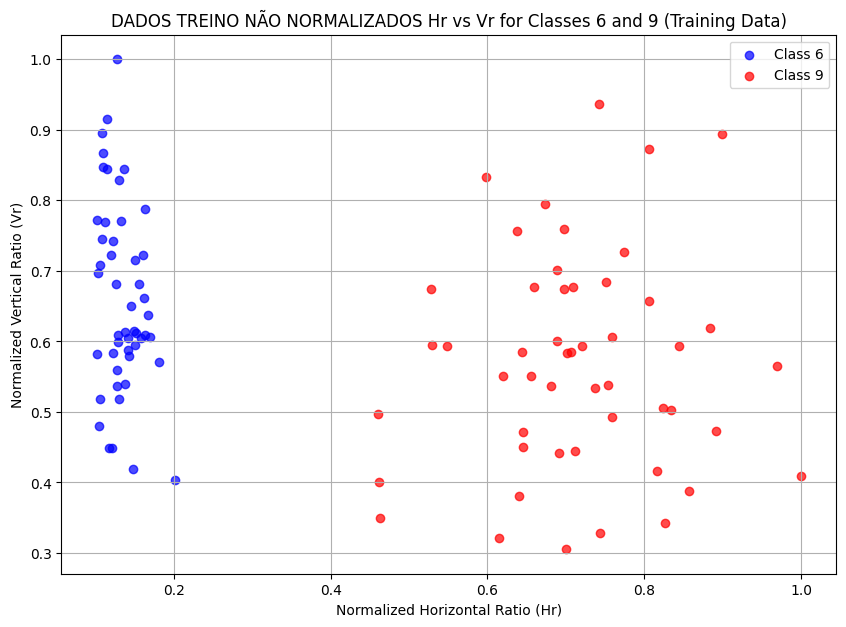

In [25]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 8
hr_6 = [item[0] for item in lista_6]
vr_6 = [item[1] for item in lista_6]

# Extract Hr and Vr for class 4
hr_9 = [item[0] for item in lista_9]
vr_9 = [item[1] for item in lista_9]

plt.figure(figsize=(10, 7))
#plt.axis('scaled')

# Plotting class 8
plt.scatter(hr_6, vr_6, color='blue', label='Class 6', alpha=0.7)

# Plotting class 4
plt.scatter(hr_9, vr_9, color='red', label='Class 9', alpha=0.7)

plt.title('DADOS TREINO NÃO NORMALIZADOS Hr vs Vr for Classes 6 and 9 (Training Data)')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()

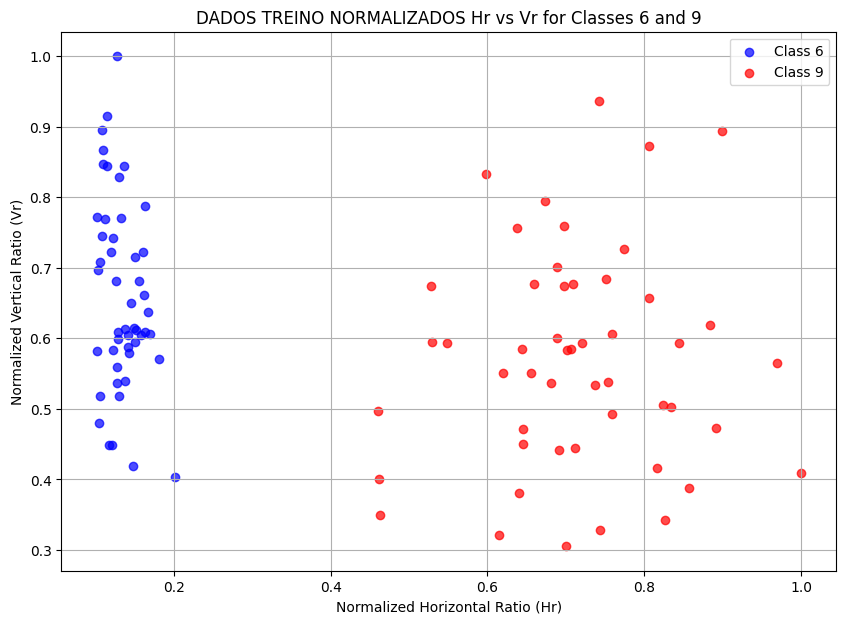

In [26]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 6 (assuming lista_6 contains [Hr, Vr] for class 6)
# hr_8 = [item[0] for item in Lista_8]
# vr_8 = [item[1] for item in Lista_8]
hr_6 = [item[0] for item in Lista_6n]
vr_6 = [item[1] for item in Lista_6n]

# Extract Hr and Vr for class 9 (assuming lista_9 contains [Hr, Vr] for class 9)
hr_9 = [item[0] for item in Lista_9n]
vr_9 = [item[1] for item in Lista_9n]

plt.figure(figsize=(10, 7))
#plt.axis('scaled')

# Plotting class 6
plt.scatter(hr_6, vr_6, color='blue', label='Class 6', alpha=0.7)

# Plotting class 4
plt.scatter(hr_9, vr_9, color='red', label='Class 9', alpha=0.7)

plt.title('DADOS TREINO NORMALIZADOS Hr vs Vr for Classes 6 and 9')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()

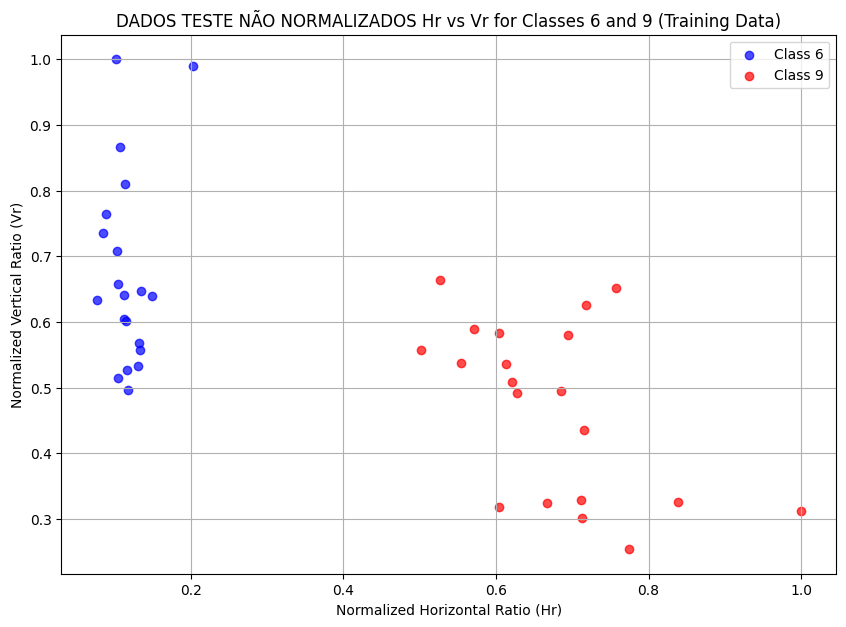

In [27]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 8
hr_6_t = [item[0] for item in Lista_6_teste]
vr_6_t = [item[1] for item in Lista_6_teste]

# Extract Hr and Vr for class 4
hr_9_t = [item[0] for item in Lista_9_teste]
vr_9_t = [item[1] for item in Lista_9_teste]

plt.figure(figsize=(10, 7))
#plt.axis('scaled')

# Plotting class 8
plt.scatter(hr_6_t, vr_6_t, color='blue', label='Class 6', alpha=0.7)

# Plotting class 4
plt.scatter(hr_9_t, vr_9_t, color='red', label='Class 9', alpha=0.7)

plt.title('DADOS TESTE NÃO NORMALIZADOS Hr vs Vr for Classes 6 and 9 (Training Data)')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def extrair_pesos_continuos(vetor_pesos_bits, num_bits_hr=8, num_bits_vr=8):
    offset = 1 if len(vetor_pesos_bits) in [17, 33] else 0

    bits_hr = vetor_pesos_bits[offset : offset + num_bits_hr]
    bits_vr = vetor_pesos_bits[offset + num_bits_hr : offset + num_bits_hr + num_bits_vr]

    w_hr = sum(b * (2 ** -(i + 1)) for i, b in enumerate(bits_hr))
    w_vr = sum(b * (2 ** -(i + 1)) for i, b in enumerate(bits_vr))

    # Se o bias não for treinado dinamicamente no circuito,
    # ele precisa ser proporcional ao centro dos dados (ex: -0.15)
    if len(vetor_pesos_bits) >= 32:
        bias = -vetor_pesos_bits[31] * 0.5
    else:
        # Bias neutro proporcional à média de Hr e Vr dos dados
        bias = -(w_hr * 0.2 + w_vr * 0.1)

    return w_hr, w_vr, bias

def plotar_fronteira_binaria(vetor_pesos_bits, label='Fronteira de Decisão', cor='purple', estilo='--'):
    """
    Calcula e plota a fronteira de decisão mantendo o foco no espaço normalizado [0, 1].
    """
    w_hr, w_vr, bias = extrair_pesos_continuos(vetor_pesos_bits)
    # if bias == 0.0000:
    #   bias = -(w_hr * 0.35 + w_vr * 0.5)
    print(f"Coeficientes calculados -> W_hr: {w_hr:.4f} | W_vr: {w_vr:.4f} | Bias: {bias:.4f}")

    # Evita divisão por zero ou números extremamente pequenos em W_vr
    if abs(w_vr) < 1e-5:
        if abs(w_hr) > 1e-5:
            hr_corte = -bias / w_hr
            plt.axvline(x=hr_corte, color=cor, linestyle=estilo, linewidth=2, label=f'{label} (Vertical)')
    else:
        # Gera valores de Hr entre 0 e 1
        hr_vals = np.linspace(-0.05, 1.05, 200)

        # Calcula Vr equivalente
        vr_vals = -(w_hr * hr_vals) / w_vr + bias

        # Plota a reta
        plt.plot(hr_vals, vr_vals, color=cor, linestyle=estilo, linewidth=2, label=label)

    # IMPORTANTE: Força o gráfico a não expandir o eixo Y além de [0, 1]
    # plt.ylim(-0.05, 1.05)
    # plt.xlim(-0.05, 1.05)

Coeficientes calculados -> W_hr: 0.1133 | W_vr: 0.3594 | Bias: -0.0586


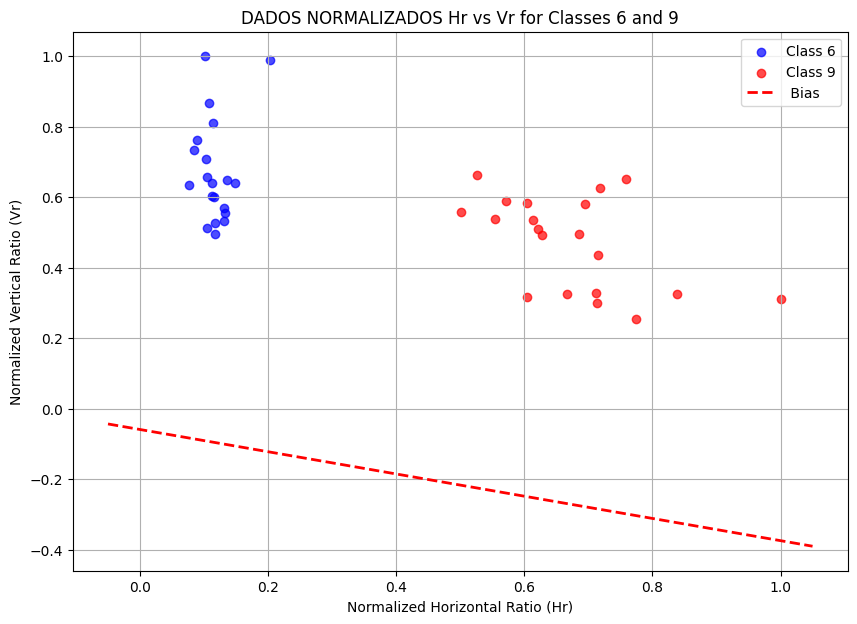

In [29]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 6 (assuming lista_6 contains [Hr, Vr] for class 6)
# hr_8 = [item[0] for item in Lista_8]
# vr_8 = [item[1] for item in Lista_8]
hr_6 = [item[0] for item in Lista_normalizada_teste_6]
vr_6 = [item[1] for item in Lista_normalizada_teste_6]

# Extract Hr and Vr for class 9 (assuming lista_9 contains [Hr, Vr] for class 9)
hr_9 = [item[0] for item in Lista_normalizada_teste_9]
vr_9 = [item[1] for item in Lista_normalizada_teste_9]

plt.figure(figsize=(10, 7))
#plt.axis('scaled')

# Plotting class 6
plt.scatter(hr_6, vr_6, color='blue', label='Class 6', alpha=0.7)

# Plotting class 4
plt.scatter(hr_9, vr_9, color='red', label='Class 9', alpha=0.7)
p=pesos_vertical_1= [
    1, 1, 1, 1, 1, 1, 1, 1,  # Hr = 1.0
    0, 0, 0, 0, 0, 0, 0, 0]
# plotar_fronteira_binaria(p, label='Sem Bias', cor='blue', estilo='--')
plotar_fronteira_binaria(vetor_w_f, label=' Bias', cor='red', estilo='--')


plt.title('DADOS NORMALIZADOS Hr vs Vr for Classes 6 and 9')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
def converter_vetor_para_float(vetor_bits, num_bits_hr=8, num_bits_vr=8):
    """
    Converte um vetor binário para os valores contínuos [0, 1] de Hr e Vr.

    Parâmetros:
      - vetor_bits: lista ou array de bits [b0, b1, b2, ...]
      - num_bits_hr: quantidade de bits dedicada ao Hr (padrão: 8)
      - num_bits_vr: quantidade de bits dedicada ao Vr (padrão: 8)

    Retorna:
      - hr_val (float): Valor contínuo de Razão Horizontal
      - vr_val (float): Valor contínuo de Razão Vertical
    """
    # Trata caso o vetor venha como array do numpy ou lista
    bits = list(vetor_bits)

    # Se o vetor possuir o bit de controle/sinal no início (ex: tamanho 17, 25, 33), salta 1 posição
    offset = 1 if len(bits) in [17, 25, 33] else 0

    # 1. Slice dos blocos de bits
    bits_hr = bits[offset : offset + num_bits_hr]
    bits_vr = bits[offset + num_bits_hr : offset + num_bits_hr + num_bits_vr]

    # 2. Conversão da parte fracionária: b0*(2^-1) + b1*(2^-2) + ... + bn*(2^-n)
    hr_val = sum(b * (2 ** -(i + 1)) for i, b in enumerate(bits_hr))
    vr_val = sum(b * (2 ** -(i + 1)) for i, b in enumerate(bits_vr))

    return hr_val, vr_val

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plotar_dados_centrados_direto(lista_dados_original, w_hr, w_vr):
    """
    Recebe a ListaDados original (sem pré-processamento de centralização),
    converte os bits, centraliza em tempo de execução e plota.
    """
    plt.figure(figsize=(8, 6))

    # 1. Extrai as coordenadas floats reais dos bits
    hrs_originais = []
    vrs_originais = []
    classes = []

    for item in lista_dados_original:
        vetor_bits = item[0]
        label = item[1]

        # Converte o vetor de bits da amostra para Hr e Vr [0, 1]
        hr_val, vr_val = converter_vetor_para_float(vetor_bits)

        hrs_originais.append(hr_val)
        vrs_originais.append(vr_val)
        classes.append(label)

    # 2. Calcula as médias reais do seu conjunto de dados
    media_hr = np.mean(hrs_originais)
    media_vr = np.mean(vrs_originais)

    print(f"Subtraindo Média Global -> Hr_médio: {media_hr:.4f} | Vr_médio: {media_vr:.4f}")

    # 3. Aplica a centralização APENAS nas coordenadas do gráfico
    hr_c6 = [hr - media_hr for hr, cl in zip(hrs_originais, classes) if cl == 0]
    vr_c6 = [vr - media_vr for vr, cl in zip(vrs_originais, classes) if cl == 0]

    hr_c9 = [hr - media_hr for hr, cl in zip(hrs_originais, classes) if cl == 1]
    vr_c9 = [vr - media_vr for vr, cl in zip(vrs_originais, classes) if cl == 1]

    # 4. Plota os pontos
    plt.scatter(hr_c6, vr_c6, color='blue', label='Classe 0 (Dígito 6)', alpha=0.8, edgecolors='k', s=50)
    plt.scatter(hr_c9, vr_c9, color='red', label='Classe 1 (Dígito 9)', alpha=0.8, edgecolors='k', s=50)

    # 5. Plota a Reta (Bias = 0)
    # A amplitude do eixo é baseada na dispersão real dos dados centralizados
    max_hr = max(abs(min(hrs_originais - media_hr)), abs(max(hrs_originais - media_hr))) * 1.3
    hr_eixo = np.linspace(-max_hr, max_hr, 200)

    if abs(w_vr) > 1e-5:
        vr_eixo = (-w_hr / w_vr) * hr_eixo
        plt.plot(hr_eixo, vr_eixo, color='purple', linestyle='--', linewidth=2, label='Fronteira (Bias=0)')
    else:
        plt.axvline(x=0, color='purple', linestyle='--', linewidth=2, label='Fronteira Vertical (Bias=0)')

    # Linhas dos eixos passando na Origem (0,0)
    plt.axhline(0, color='black', linewidth=1, linestyle=':')
    plt.axvline(0, color='black', linewidth=1, linestyle=':')

    # Define limites dinâmicos para não encolher o gráfico
    plt.xlim(-max_hr, max_hr)
    plt.ylim(-max_hr, max_hr)

    plt.title("Dados Centralizados na Origem $(0,0)$")
    plt.xlabel("Razão Horizontal Centrada ($H_r'$)")
    plt.ylabel("Razão Vertical Centrada ($V_r'$)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

Subtraindo Média Global -> Hr_médio: 0.2756 | Vr_médio: 0.2981


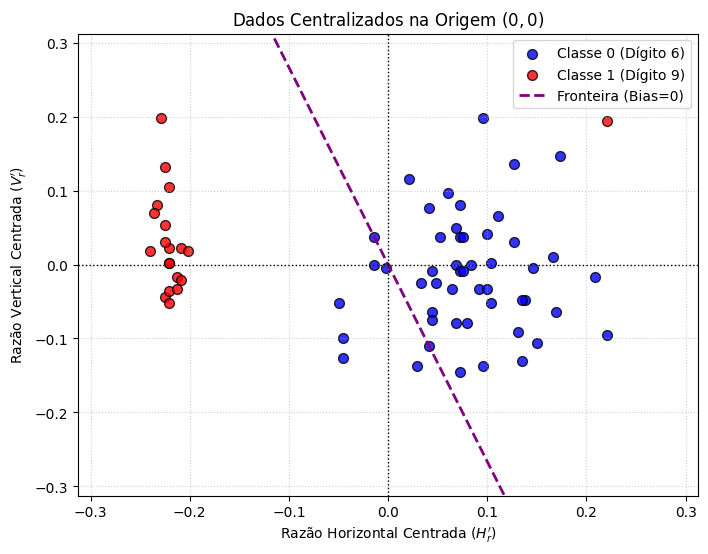

In [32]:
# Passe a sua ListaDados original (a mesma que você usava antes)
plotar_dados_centrados_direto(ListaDados_teste, w_hr=0.0312, w_vr=0.0117)

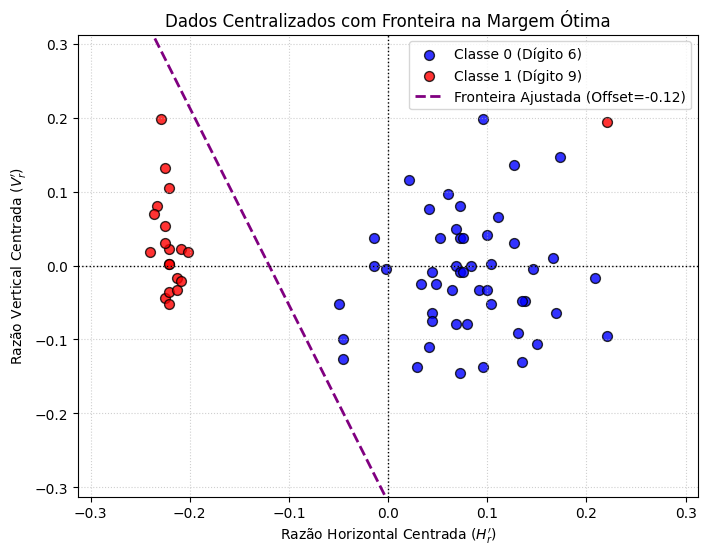

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plotar_dados_centrados_com_margem(lista_dados_original, w_hr, w_vr, offset_margem=-0.12):
    plt.figure(figsize=(8, 6))

    # 1. Extrai coordenadas dos bits originais
    hrs_originais = []
    vrs_originais = []
    classes = []

    for item in lista_dados_original:
        vetor_bits, label = item[0], item[1]
        hr_val, vr_val = converter_vetor_para_float(vetor_bits)
        hrs_originais.append(hr_val)
        vrs_originais.append(vr_val)
        classes.append(label)

    # 2. Centraliza pela média global
    media_hr = np.mean(hrs_originais)
    media_vr = np.mean(vrs_originais)

    hr_c6 = [hr - media_hr for hr, cl in zip(hrs_originais, classes) if cl == 0]
    vr_c6 = [vr - media_vr for vr, cl in zip(vrs_originais, classes) if cl == 0]

    hr_c9 = [hr - media_hr for hr, cl in zip(hrs_originais, classes) if cl == 1]
    vr_c9 = [vr - media_vr for vr, cl in zip(vrs_originais, classes) if cl == 1]

    # 3. Plota os pontos
    plt.scatter(hr_c6, vr_c6, color='blue', label='Classe 0 (Dígito 6)', alpha=0.8, edgecolors='k', s=50)
    plt.scatter(hr_c9, vr_c9, color='red', label='Classe 1 (Dígito 9)', alpha=0.8, edgecolors='k', s=50)

    # 4. Plota a Reta Deslocada para o meio da Margem
    max_hr = max(abs(min(hrs_originais - media_hr)), abs(max(hrs_originais - media_hr))) * 1.3
    hr_eixo = np.linspace(-max_hr, max_hr, 200)

    if abs(w_vr) > 1e-5:
        # Equação da reta com deslocamento (offset):
        # W_hr * (Hr' - offset) + W_vr * Vr' = 0  =>  Vr' = (-W_hr / W_vr) * (Hr' - offset)
        vr_eixo = (-w_hr / w_vr) * (hr_eixo - offset_margem)
        plt.plot(hr_eixo, vr_eixo, color='purple', linestyle='--', linewidth=2, label=f'Fronteira Ajustada (Offset={offset_margem})')
    else:
        plt.axvline(x=offset_margem, color='purple', linestyle='--', linewidth=2, label=f'Fronteira Vertical (Offset={offset_margem})')

    # Eixos de referência centrados
    plt.axhline(0, color='black', linewidth=1, linestyle=':')
    plt.axvline(0, color='black', linewidth=1, linestyle=':')

    plt.xlim(-max_hr, max_hr)
    plt.ylim(-max_hr, max_hr)
    plt.title("Dados Centralizados com Fronteira na Margem Ótima")
    plt.xlabel("Razão Horizontal Centrada ($H_r'$)")
    plt.ylabel("Razão Vertical Centrada ($V_r'$)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

# Exemplo de execução:
plotar_dados_centrados_com_margem(ListaDados_teste, w_hr=0.0312, w_vr=0.0117, offset_margem=-0.12)

In [34]:
def calcular_acuracia_com_offset(lista_dados, w_hr, w_vr, media_hr, media_vr, offset_margem=-0.12):
    acertos = 0

    for item in lista_dados:
        vetor_bits, label_real = item[0], item[1]
        hr, vr = converter_vetor_para_float(vetor_bits)

        # Centraliza o ponto
        hr_c = hr - media_hr
        vr_c = vr - media_vr

        # Avalia a combinação linear com o desvio de margem
        # Ponto > 0 pertence a uma classe, < 0 pertence a outra
        valor_decisao = w_hr * (hr_c - offset_margem) + w_vr * vr_c

        # Predição: se valor_decisao >= 0 -> Classe 0, senao Classe 1
        predicao = 0 if valor_decisao >= 0 else 1

        if predicao == label_real:
            acertos += 1

    acuracia = (acertos / len(lista_dados)) * 100
    print(f"Acurácia Reais com Offset ({offset_margem}): {acuracia:.2f}%")
    return acuracia

In [35]:
hrs_originais = []
vrs_originais = []
classes = []
lista_dados_original = ListaDados_teste
for item in lista_dados_original:
    vetor_bits, label = item[0], item[1]
    hr_val, vr_val = converter_vetor_para_float(vetor_bits)
    hrs_originais.append(hr_val)
    vrs_originais.append(vr_val)
    classes.append(label)

# 2. Centraliza pela média global
media_hr = np.mean(hrs_originais)
media_vr = np.mean(vrs_originais)
calcular_acuracia_com_offset(ListaDados_teste, w_hr=0.0312, w_vr=0.0117,media_hr=media_hr, media_vr=media_vr, offset_margem=-0.12)

Acurácia Reais com Offset (-0.12): 98.57%


98.57142857142858